## Introducción

El objetivo de este proyecto es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
El análisis se basa en datos reales de TomTom Traffic Index y OECD Cities. El siguiente proceso demuestra la limpieza, unión y análisis de los datos para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## Paso 1: Cargar y explorar
En esta etapa, se valida que los archivos se carguen correctamente, revisamos sus columnas y tipos de datos y detectamos posibles inconsistencias.

In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspeccionamos su estructura, tipos de datos, columnas y valores faltantes.
Notamos las columnas que necesiten limpieza y luego estandarizamos los nombres de columnas.

In [5]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo `object`, lo cual dificulta un análisis exitoso. Es necesario convertirlas a tipo `datetime`.
- Las columnas `Country` y `City` son de tipo `object`. Es necesario convertirlas a tipo `string`. 
- No hay valores nulos en ninguna columna.

In [6]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)` son de tipo `object`. Es necesario convertirlas a tipo `float`.
- Las columnas `City` y `Country` son de tipo `object`. Es necesario convertirlas a tipo `string`.

### 2.1 Renombrar columnas

Estandarizaramos los nombres de columnas para evitar errores y facilitar la unión de los datasets.
- Cambiamos los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verificamos que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={

    "Country": "country",
    "City": "city",
    "UpdateTimeUTC": "update_time_utc",
    "JamsDelay": "jams_delay",
    "TrafficIndexLive": "traffic_index_live",
    "JamsLengthInKms": "jams_length_in_km",
    "JamsCount": "jams_count",
    "TrafficIndexWeekAgo": "traffic_index_week_ago",
    "UpdateTimeUTCWeekAgo":"update_time_utc_week_ago",
    "TravelTimeLivePer10KmsMins": "travel_time_live_per_10_kms_mins",
    "TravelTimeHistoricPer10KmsMins": "travel_time_historic_per_10_kms_mins",
    "MinsDelay": "mins_delay"

})

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_km', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    "Year": "year",
    "City": "city",
    "Country": "country",
    "City GDP/capita": "city_gdp_capita",
    "Unemployment %": "unemployment_pct",
    "PM2.5 (μg/m³)": "pm25",
    "Population (M)": "population_m"
})

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.2 Corregir formatos numéricos y de fecha

Aseguramos que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

- Convertimos las columnas de fecha de `traffic` a formato `datetime`.
- En el dataset `eco`, limpiamos los valores numéricos:
    - En `city_gdp_capita`: eliminamos separadores de miles (`.`) y reemplazamos las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: eliminamos el símbolo de porcentaje (`%`) y reemplazamos las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplazamos las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, creamos una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"], errors="coerce")
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors="coerce")

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_length_in_km                     1004464 non-null  float64       
 6   jams_count                            1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

In [10]:
# Limpiar separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace("%", "").str.replace(",", ".").astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(",", ".").astype(float)


# Calcular la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco["population_m"] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## Paso 3: Extraer año y filtrar

Extraemos el año para filtrar la información y trabajar solo con el período más reciente y relevante (en este caso, los registros del 2024).

- Como el DataFrame `traffic` no tiene una columna de año, utilizamos el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtramos las filas donde el año sea **2024**.
- Utilizamos `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic["update_time_utc"].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_km,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Crear copias de dataframes y filtrar por año 2024
traffic_2024 = traffic.copy()
traffic_2024 = traffic_2024[traffic_2024["year"] == 2024]

eco_2024 = eco.copy()
eco_2024 = eco_2024[eco_2024["year"] == 2024]

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_km,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**, calculamos los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

- Agrupamos los datos por `city`, `country` y `year`.
- Calculamos el promedio solo de las métricas de tráfico más relevantes: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guardamos el resultado como `traffic_city_year_2024`, mantenemos las columnas como variables (no índices).


In [15]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =  traffic_2024.groupby(["city", "country", "year"])[
    ["jams_delay", "traffic_index_live", "jams_length_in_km",
     "jams_count", "mins_delay", "travel_time_live_per_10_kms_mins",
     "travel_time_historic_per_10_kms_mins"]].agg("mean").reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_km,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### **Análisis**

Aquí, analizamos qué ciudad tiene el mayor tiempo promedio de tráfico, encontrando que se trata de Ciudad de México (`mexico-city`).

In [14]:
# Encontrar qué ciudad tiene el mayor tiempo promedio de tráfico
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_km,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694



---

## Paso 5: Unir movilidad y economía

Combinamos los datasets para analizar cómo se relacionan los indicadores económicos con los de movilidad.

- Seleccionamos las columnas relevantes de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usamos `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Unimos ambos DataFrames y definimos como **claves de unión** a `city` y `year`.
- Mantenemos solo las ciudades y años presentes en ambos datasets.
- Guardamos el resultado en una nueva variable llamada `merged` y mostramos las primeras 5 filas.


In [46]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_km','jams_count','mins_delay',
             'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=["city", "year"], how="inner")

# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_km,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## Paso 6: Visualización y análisis de relaciones

Analizamos visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

- Usamos las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualizamos la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Comparamos ambas variables para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.

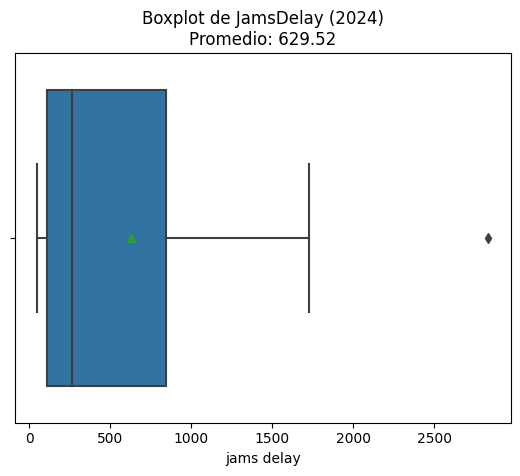

In [34]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, x="jams_delay", showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel("jams delay")
plt.show()


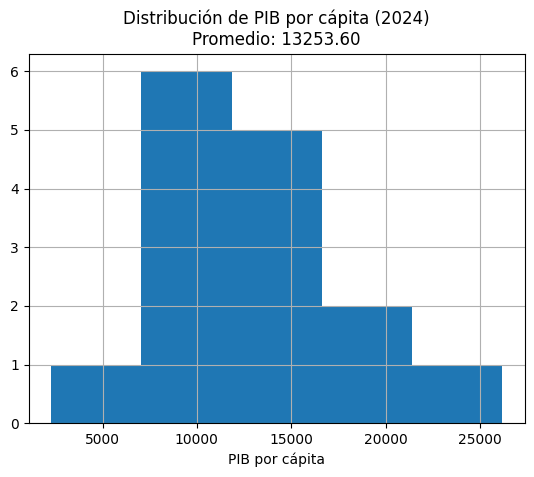

In [37]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged["city_gdp_capita"].hist(bins=5)

#Obtener media y establecer título de gráfico
gdp_mean = merged["city_gdp_capita"].mean()
plt.title(f"Distribución de PIB por cápita (2024)\nPromedio:{gdp_mean: .2f}")
plt.xlabel("PIB por cápita")
plt.show()

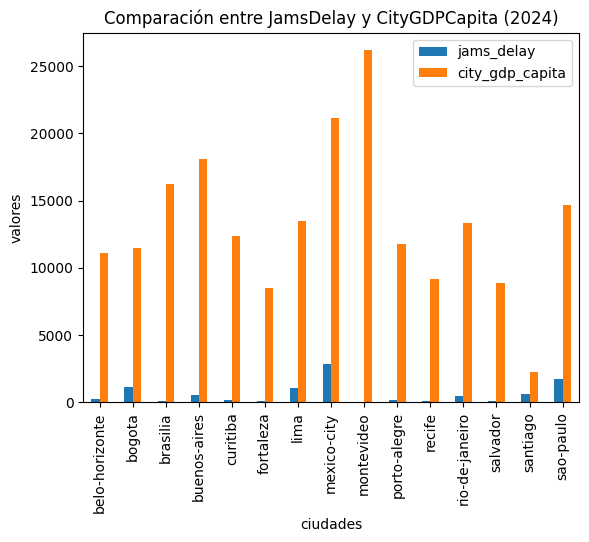

In [38]:

# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad

merged.plot(kind="bar", x="city", y=['jams_delay', 'city_gdp_capita'])
plt.title("Comparación entre JamsDelay y CityGDPCapita (2024)")
plt.xlabel("ciudades")
plt.xticks(rotation=90)
plt.ylabel("valores")
plt.show()


### **Reflexiones**

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?  ¿O sucede lo contrario, o no existe una relación clara?

Encotramos que:
- Las ciudades con mayor PIB por cápita no presentan necesariamente mayor congestión. Por ejemplo, el PIB/cápita de Montevideo es el más alto entre las ciudades latinoamericanas analizadas. Sin embargo, su congestión de tráfico es mínima.
- Por otro lado, entre las ciudades analizadas Santiago tiene un PIB/cápita más bajo pero una congestión más alta que Montevideo, es decir, la proporción entre congestión-PIB/cápita en Santiago es MAYOR a la de Montevideo.
- Por lo tanto, no podemos establecer si existe una relación clara entre congestión de tráfico y PIB/cápita.
- *Nota importate:* Este gráfico de barras no es suficiente para analizar a detalle la relación entre congestión de tráfico y PIB/cápita, debido a que las unidades de ambas categorías son distintas en escala (minutos para jams_delay y dólares para GDP). Esto causa que la relación entre ambas categorías no se pueda visualizar adecuadamente.
- Mejores respuestas se podrían extraer si se realiza un análisis que mida la proporción entre congestión-PIB/cápita.


---

## Paso 7: Exportar y documentar resultados

Consolidamos todo tu trabajo: guardamos el dataset limpio y creamos un resumen que documenta los resultados del proyecto.

- Exportamos el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usamos `index=False` para no incluir el índice.


In [39]:
# Exportar el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

## Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).


In [48]:
ciudades = merged["city"].unique()
num_ciudades = merged["city"].nunique()
paises = merged["country"].unique()
num_paises = merged["country"].nunique()

print(f"Ciudades analizadas: {ciudades}\nCantidad de ciudades: {num_ciudades}\nPaíses analizados: {paises}\nCantidad de países: {num_paises}")

Ciudades analizadas: ['belo-horizonte' 'bogota' 'brasilia' 'buenos-aires' 'curitiba'
 'fortaleza' 'lima' 'mexico-city' 'montevideo' 'porto-alegre' 'recife'
 'rio-de-janeiro' 'salvador' 'santiago' 'sao-paulo']
Cantidad de ciudades: 15
Países analizados: ['BRA' 'COL' 'ARG' 'PER' 'MEX' 'URY' 'CHL']
Cantidad de países: 7



---

# Resumen ejecutivo (plantilla)

**Contexto & objetivo:**  
- La pregunta central de nuestro análisis fue: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Analizamos dos datasets (`tomtom_traffic` y `oecd_city_economy`) para responder la pregunta, enfocándonos específicamente en la congestión de tráfico en minutos (`jams_delay`) por ciudad en el año 2024 y en el PIB/cápita de cada ciudad (`city_gdp_capita`).

**Cobertura de datos:**  
- Analizamos el año **2024**, enfocándonos en **15 ciudades** de América Latina en los siguientes **7 países**: Brasil, Colombia, Argentina, Perú, México, Uruguay, Chile.

**Metodología (alto nivel):**  
- Limpiamos los formatos de ambos datasets, estandarizando los títulos y valores de columnas clave y convirtiendo las columnas más relevantes para al análisis en un datatype adecuado: de `object` a `string` o de `object` a `datetime`.
- Extraimos datos del año por analizar (2024), creando nuevos dataframes (`traffic_2024` y `eco_2024`)para evitar la edición del dataframe inicial.
- Medimos el promedio de las métricas de tráfico por ciudad, agrupando los datos por ciudad, país y año en `traffic_city_year_2024`.
- Realizamos un `inner join` entre ambos datasets una vez limpios y con las columnas relevantes, haciendo el `merge` entre `traffic_2024_small` y `eco_2024_small`.
- El `inner join` devolvió resultados enfocados en ciudades latinoamericanas.

**Hallazgos iniciales:**  
- El análisis muestra asociaciones descriptivas, pero no permite establecer causalidad entre PIB/cápita y congestión de tráfico. Además, la comparación mediante un gráfico de barras debe interpretarse con cuidado porque las dos variables tienen unidades y escalas diferentes (minutos vs dólares).

**Recomendaciones**  
- Se sugiere una investigación más a fondo. Analizar variables adicionales en los datasets originales como nivel de desempleo y población puede enriquecer el análisis.
- Es importante calcular una correlación estadística entre `jams_delay` y `city_gdp_capita`, pues el actual análisis no puede establecer que existe una correlación significativa entre ambas.